In [1]:
import pandas as pd
import numpy as np

from typing import List

import re

from collections import defaultdict
import glob
import seaborn as sns
import matplotlib.pyplot as plt
import json
from typing import List, Any, Set, Dict
from tqdm import tqdm
import re
sns.set()
import math


## Load all reports

In [2]:
import json
import glob
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm  # Make sure to install this: !pip install tqdm

def load_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

if __name__ == '__main__':
    file_pattern = "data/*.json"
    files = glob.glob(file_pattern)
    
    data_list = []
    
    # We use a context manager for the executor
    with ProcessPoolExecutor() as executor:
        # map() returns an iterator; we wrap it with tqdm to get the progress bar
        # total=len(files) helps tqdm estimate the time remaining
        report_folder = 'outputs/reports/offline_wcd_igraph'
        report_files = glob.glob(report_folder + "/*.json")
        results = executor.map(load_json, report_files)
        
        # This loop pulls results from the pool as they finish
        for result in tqdm(results, total=len(report_files), desc="Loading JSONs"):
            data_list.append(result)
            
    print(f"Finished loading {len(data_list)} files.")

Loading JSONs: 100%|██████████| 4176/4176 [01:28<00:00, 47.16it/s] 


Finished loading 4176 files.


## Find all legacy reports with no system prompt

In [3]:
prompt_file = "wildguard_prompts_larger.parquet"
prompts_df = pd.read_parquet(prompt_file)
prompts = prompts_df['prompt'].tolist()
harmful_prompts = prompts[:30]
non_harmful_prompts = prompts[30:]

# agg params
temperature = 0.4
top_p = 0.8

def agg_stats(prompt_list: List[str], temp: float, top_p: float):
    file_confirmed = 0
    wcds = defaultdict(list)
    pruned_masses = defaultdict(list)

    for prompt in tqdm(prompt_list, desc="Processing prompts"):
        # find the file corresponding to the prompt
        for report in data_list:
            if True:
                if re.sub(r'[^a-zA-Z0-9]', '', report["prompt"].strip()) == re.sub(r'[^a-zA-Z0-9]', '', prompt.strip()) and float(report["temperature"]) == temp and float(report["top_p"]) == top_p and "system_prompt_id" not in report:  # match
                    file_confirmed += 1
                    intervention = report["interventions"][0]

                    if intervention["intervention"] == "none":
                        intervention_slug = "none"
                    else:
                        intervention_slug = str(intervention["intervention"]) + "_" + str(intervention["k"]) + "_" + str(intervention['selection']) + "_" + str(intervention['top_n'])

                    wcds[intervention_slug].append(intervention["wcd"] if intervention["wcd"] > 0 else 0)
                    pruned_masses[intervention_slug].append(intervention["mass_nucleus_after_intervention"])
    print(file_confirmed)
    return wcds, pruned_masses

harmful_wcds, harmful_pruned_masses = agg_stats(harmful_prompts, temperature, top_p)
non_harmful_wcds, non_harmful_pruned_masses = agg_stats(non_harmful_prompts, temperature, top_p)

Processing prompts: 100%|██████████| 30/30 [00:10<00:00,  2.92it/s]


870


Processing prompts: 100%|██████████| 30/30 [00:09<00:00,  3.29it/s]

870


## Find all new reports with system prompt

In [4]:
# agg params
temperature = 0.4
top_p = 0.8

def agg_stats(prompt_list: List[str], temp: float, top_p: float):
    file_confirmed = 0
    wcds = defaultdict(list)
    pruned_masses = defaultdict(list)

    for prompt in tqdm(prompt_list, desc="Processing prompts"):
        # find the file corresponding to the prompt
        for report in data_list:
            if True:
                if re.sub(r'[^a-zA-Z0-9]', '', prompt.strip()) in re.sub(r'[^a-zA-Z0-9]', '', report["prompt"].strip()) and float(report["temperature"]) == temp and float(report["top_p"]) == top_p and "system_prompt_id" in report and report["system_prompt_id"] == "safety_system_prompt":  # match
                    file_confirmed += 1
                    intervention = report["interventions"][0]

                    if intervention["intervention"] == "none":
                        intervention_slug = "none"
                    else:
                        intervention_slug = str(intervention["intervention"]) + "_" + str(intervention["k"]) + "_" + str(intervention['selection']) + "_" + str(intervention['top_n'])

                    wcds[intervention_slug].append(intervention["wcd"] if intervention["wcd"] > 0 else 0)
                    pruned_masses[intervention_slug].append(intervention["mass_nucleus_after_intervention"])
    print(file_confirmed)
    return wcds, pruned_masses

safety_harmful_wcds, safety_harmful_pruned_masses = agg_stats(harmful_prompts, temperature, top_p)
safety_non_harmful_wcds, safety_non_harmful_pruned_masses = agg_stats(non_harmful_prompts, temperature, top_p)

Processing prompts:   0%|          | 0/30 [00:00<?, ?it/s]

Processing prompts: 100%|██████████| 30/30 [00:10<00:00,  2.91it/s]


870


Processing prompts: 100%|██████████| 30/30 [00:09<00:00,  3.19it/s]

870


## Transform to DF

In [5]:
import pandas as pd
harmful_wcds_df = pd.DataFrame(harmful_wcds)
non_harmful_wcds_df = pd.DataFrame(non_harmful_wcds)
harmful_pruned_masses_df = pd.DataFrame(harmful_pruned_masses)
non_harmful_pruned_masses_df = pd.DataFrame(non_harmful_pruned_masses)

harmful_wcds_df["system_prompt"] = safety_harmful_wcds["none"]
non_harmful_wcds_df["system_prompt"] = safety_non_harmful_wcds["none"]
harmful_pruned_masses_df["system_prompt"] = safety_harmful_pruned_masses["none"]
non_harmful_pruned_masses_df["system_prompt"] = safety_non_harmful_pruned_masses["none"]

cols = [
    col
    for col in harmful_wcds_df.columns
    if "30" not in col and "40" not in col and "random" not in col
]

harmful_wcds_df = harmful_wcds_df / harmful_wcds_df["none"].values[:, None]
non_harmful_wcds_df = non_harmful_wcds_df / non_harmful_wcds_df["none"].values[:, None]
harmful_pruned_masses_df = harmful_pruned_masses_df / harmful_pruned_masses_df["none"].values[:, None]
non_harmful_pruned_masses_df = non_harmful_pruned_masses_df / non_harmful_pruned_masses_df["none"].values[:, None]

harmful_wcds_df = harmful_wcds_df[cols]
non_harmful_wcds_df = non_harmful_wcds_df[cols]
harmful_pruned_masses_df = harmful_pruned_masses_df[cols]
non_harmful_pruned_masses_df = non_harmful_pruned_masses_df[cols]
combined_wcds_df = pd.concat([harmful_wcds_df, non_harmful_wcds_df], axis=0)
combined_pruned_masses_df = pd.concat([harmful_pruned_masses_df, non_harmful_pruned_masses_df], axis=0)

In [6]:
combined_wcds_df.shape

(60, 12)

In [7]:
import pandas as pd
safety_harmful_wcds_df = pd.DataFrame(safety_harmful_wcds)
safety_non_harmful_wcds_df = pd.DataFrame(safety_non_harmful_wcds)
safety_harmful_pruned_masses_df = pd.DataFrame(safety_harmful_pruned_masses)
safety_non_harmful_pruned_masses_df = pd.DataFrame(safety_non_harmful_pruned_masses)

cols = [
    col
    for col in safety_harmful_wcds_df.columns
    if "30" not in col and "40" not in col and "random" not in col
]
safety_harmful_wcds_df = safety_harmful_wcds_df / safety_harmful_wcds_df["none"].values[:, None]
safety_non_harmful_wcds_df = safety_non_harmful_wcds_df / safety_non_harmful_wcds_df["none"].values[:, None]
safety_harmful_pruned_masses_df = safety_harmful_pruned_masses_df / safety_harmful_pruned_masses_df["none"].values[:, None]
safety_non_harmful_pruned_masses_df = safety_non_harmful_pruned_masses_df / safety_non_harmful_pruned_masses_df["none"].values[:, None]

safety_harmful_wcds_df = safety_harmful_wcds_df[cols]
safety_non_harmful_wcds_df = safety_non_harmful_wcds_df[cols]
safety_harmful_pruned_masses_df = safety_harmful_pruned_masses_df[cols]
safety_non_harmful_pruned_masses_df = safety_non_harmful_pruned_masses_df[cols]
combined_safety_wcds_df = pd.concat([safety_harmful_wcds_df, safety_non_harmful_wcds_df], axis=0)
combined_safety_pruned_masses_df = pd.concat([safety_harmful_pruned_masses_df, safety_non_harmful_pruned_masses_df], axis=0)

In [8]:
combined_safety_wcds_df.shape

(60, 11)

## Get aggregates for overleaf

In [9]:
## success rate
print("Success Rate for Combined WCDs:")
print("=========================")
for col in combined_wcds_df.columns:
    print(col, "success rate:", round((combined_wcds_df[col] < 1).mean(), 2))


# wcd reduction
print("\nMean WCD Reduction for Combined WCDs:")
print("=========================")
for col in combined_wcds_df.columns:
    print(col, "mean WCD reduction:", round(combined_wcds_df[combined_wcds_df[col] < 1][col].mean(), 2))

# probability mass reduction
print("\nMean Probability Mass Reduction for Combined Pruned Masses:")
print("=========================")
for col in combined_pruned_masses_df.columns:
    print(col, "mean probability mass reduction:", round(combined_pruned_masses_df[combined_wcds_df[col] < 1][col].mean(), 2))

Success Rate for Combined WCDs:
fixed_k_10_extreme_3 success rate: 0.02
fixed_k_20_min_1 success rate: 0.13
fixed_k_10_max_1 success rate: 0.17
fixed_k_10_extreme_1 success rate: 0.17
fixed_k_20_extreme_3 success rate: 0.0
fixed_k_20_max_1 success rate: 0.12
fixed_k_20_both_sides_1 success rate: 0.0
fixed_k_10_min_1 success rate: 0.15
fixed_k_10_both_sides_1 success rate: 0.07
fixed_k_20_extreme_1 success rate: 0.15
none success rate: 0.0
system_prompt success rate: 0.42

Mean WCD Reduction for Combined WCDs:
fixed_k_10_extreme_3 mean WCD reduction: 0.87
fixed_k_20_min_1 mean WCD reduction: 0.84
fixed_k_10_max_1 mean WCD reduction: 0.81
fixed_k_10_extreme_1 mean WCD reduction: 0.85
fixed_k_20_extreme_3 mean WCD reduction: nan
fixed_k_20_max_1 mean WCD reduction: 0.82
fixed_k_20_both_sides_1 mean WCD reduction: nan
fixed_k_10_min_1 mean WCD reduction: 0.87
fixed_k_10_both_sides_1 mean WCD reduction: 0.87
fixed_k_20_extreme_1 mean WCD reduction: 0.82
none mean WCD reduction: nan
system_p

In [10]:
## success rate
print("Success Rate for Combined WCDs:")
print("=========================")
for col in combined_safety_wcds_df.columns:
    print(col, "success rate:", round((combined_safety_wcds_df[col] < 1).mean(), 2))


# wcd reduction
print("\nMean WCD Reduction for Combined WCDs:")
print("=========================")
for col in combined_safety_wcds_df.columns:
    print(col, "mean WCD reduction:", round(combined_safety_wcds_df[combined_safety_wcds_df[col] < 1][col].mean(), 2))

# probability mass reduction
print("\nMean Probability Mass Reduction for Combined Pruned Masses:")
print("=========================")
for col in combined_safety_pruned_masses_df.columns:
    print(col, "mean probability mass reduction:", round(combined_safety_pruned_masses_df[combined_safety_wcds_df[col] < 1][col].mean(), 2))

Success Rate for Combined WCDs:
fixed_k_20_extreme_1 success rate: 0.1
fixed_k_10_extreme_1 success rate: 0.17
fixed_k_20_min_1 success rate: 0.1
fixed_k_10_both_sides_1 success rate: 0.02
fixed_k_10_extreme_3 success rate: 0.0
fixed_k_20_both_sides_1 success rate: 0.0
fixed_k_10_min_1 success rate: 0.13
fixed_k_20_extreme_3 success rate: 0.0
none success rate: 0.0
fixed_k_10_max_1 success rate: 0.15
fixed_k_20_max_1 success rate: 0.12

Mean WCD Reduction for Combined WCDs:
fixed_k_20_extreme_1 mean WCD reduction: 0.8
fixed_k_10_extreme_1 mean WCD reduction: 0.91
fixed_k_20_min_1 mean WCD reduction: 0.8
fixed_k_10_both_sides_1 mean WCD reduction: 0.91
fixed_k_10_extreme_3 mean WCD reduction: nan
fixed_k_20_both_sides_1 mean WCD reduction: nan
fixed_k_10_min_1 mean WCD reduction: 0.9
fixed_k_20_extreme_3 mean WCD reduction: nan
none mean WCD reduction: nan
fixed_k_10_max_1 mean WCD reduction: 0.85
fixed_k_20_max_1 mean WCD reduction: 0.8

Mean Probability Mass Reduction for Combined Pru

Plot saved as 'metric_hist.pdf' ready for your LaTeX document.


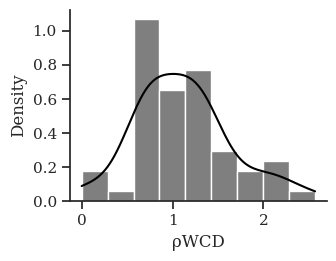

In [12]:
# 1. Professional settings (using a standard serif font that mimics LaTeX)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10  # Standard point size for document text
})

# 2. Dimensions based on your Overleaf column width (239.39438pt / 72.27)
width_in_inches = 3.3125
fig, ax = plt.subplots(figsize=(width_in_inches, width_in_inches * 0.75))

# 3. Plotting
# Note: Since usetex is off, use standard text for labels
sns.histplot(combined_wcds_df['system_prompt'], kde=True, ax=ax, color='black', stat="density")

# 4. Styling
sns.set_style("ticks")
sns.despine()
ax.set_xlabel("ρWCD") # Replace with your actual metric name
ax.set_ylabel("Density")

# 5. Export as a vector PDF
plt.savefig("metric_hist.pdf", bbox_inches='tight')
print("Plot saved as 'metric_hist.pdf' ready for your LaTeX document.")

Plot saved as 'metric_hist.pdf' with 0.25 bins and 2+ clamping.


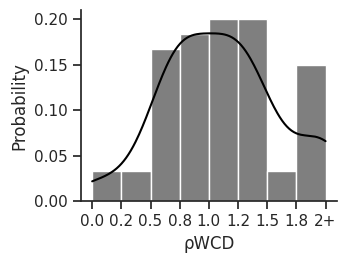

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare data: Clamp values >= 2 to 2
# This puts all "2 and above" values into the final bin
clamped_series = combined_wcds_df['system_prompt'].clip(upper=2)

# 2. Setup Plot
width_in_inches = 3.3125
fig, ax = plt.subplots(figsize=(width_in_inches, width_in_inches * 0.75))

# 3. Plotting
# Use defined bins (0 to 2 in 0.25 increments)
bins = np.arange(0, 2 + 0.25, 0.25)
sns.histplot(clamped_series, bins=bins, kde=True, ax=ax, color='black', stat="probability")

# 4. Custom Ticks
# Set x-ticks from 0 to 2 with 0.25 steps
ax.set_xticks(np.arange(0, 2 + 0.1, 0.25))
# Optional: Label the final tick as "2+"
labels = [f"{x:.1f}" for x in np.arange(0, 2, 0.25)] + ["2+"]
ax.set_xticklabels(labels)

# 5. Styling
sns.set_style("ticks")
sns.despine()
ax.set_xlabel("ρWCD")
ax.set_ylabel("Probability")

# 6. Save
plt.savefig("metric_hist.pdf", bbox_inches='tight')
print("Plot saved as 'metric_hist.pdf' with 0.25 bins and 2+ clamping.")

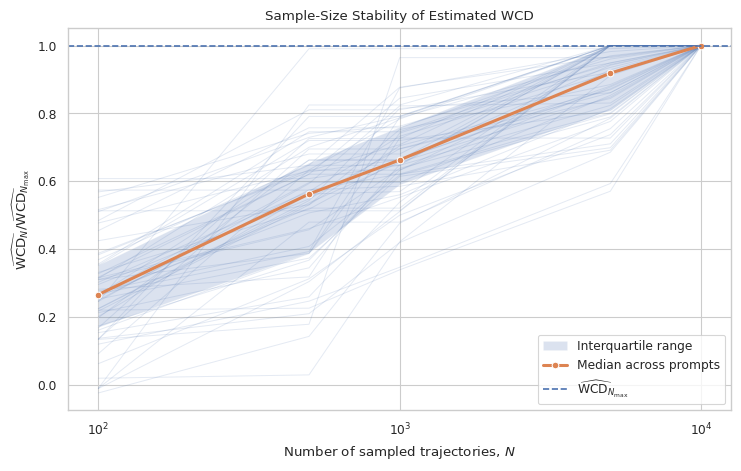

,sample_size_used,median,mean,q25,q75,count
0,100,0.266055,0.274014,0.170805,0.353966,59
1,500,0.562500,0.532322,0.390091,0.654896,59
2,1000,0.662791,0.669001,0.590718,0.759907,59
3,5000,0.918605,0.886142,0.810667,1.000000,59
4,10000,1.000000,1.000000,1.000000,1.000000,59


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Folder containing the per-prompt CSV files.
CSV_FOLDER = Path("./outputs/reports/offline_wcd_igraph_baseline_samples/")

# Optional PDF output.
OUTPUT_PATH = "./wcd_stability_normalized.pdf"


required_columns = {
    "jsonl_file",
    "sample_size_used",
    "baseline_wcd",
}

csv_files = sorted(CSV_FOLDER.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {CSV_FOLDER}")

frames = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        print(
            f"Skipping {csv_file.name}: "
            f"missing {sorted(missing_columns)}"
        )
        continue

    frames.append(df)

if not frames:
    raise ValueError("No valid CSV files were found.")

data = pd.concat(frames, ignore_index=True)

data["sample_size_used"] = pd.to_numeric(
    data["sample_size_used"],
    errors="coerce",
)
data["baseline_wcd"] = pd.to_numeric(
    data["baseline_wcd"],
    errors="coerce",
)

data = data.dropna(
    subset=["jsonl_file", "sample_size_used", "baseline_wcd"]
)

data["sample_size_used"] = data["sample_size_used"].astype(int)

# Average repeated runs for the same prompt and sample size.
# This also supports multiple seeds.
data = (
    data.groupby(
        ["jsonl_file", "sample_size_used"],
        as_index=False,
    )
    .agg(baseline_wcd=("baseline_wcd", "mean"))
)

# Find the WCD at the largest available sample size for each prompt.
largest_sample = (
    data.sort_values("sample_size_used")
    .groupby("jsonl_file", as_index=False)
    .tail(1)
    [["jsonl_file", "baseline_wcd"]]
    .rename(columns={"baseline_wcd": "largest_sample_wcd"})
)

data = data.merge(
    largest_sample,
    on="jsonl_file",
    how="left",
)

# Exclude prompts for which normalization is undefined.
num_zero_wcd = data.loc[
    data["largest_sample_wcd"] == 0,
    "jsonl_file",
].nunique()

if num_zero_wcd:
    print(
        f"Excluding {num_zero_wcd} prompts whose "
        "largest-sample WCD is zero."
    )

data = data[data["largest_sample_wcd"] > 0].copy()

data["relative_wcd"] = (
    data["baseline_wcd"] / data["largest_sample_wcd"]
)

# Compute summary statistics across prompts.
summary = (
    data.groupby("sample_size_used")["relative_wcd"]
    .agg(
        median="median",
        mean="mean",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        count="count",
    )
    .reset_index()
    .sort_values("sample_size_used")
)

sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(7.5, 4.8))

# One faint line per prompt.
sns.lineplot(
    data=data,
    x="sample_size_used",
    y="relative_wcd",
    units="jsonl_file",
    estimator=None,
    linewidth=0.7,
    alpha=0.15,
    legend=False,
    ax=ax,
)

# Interquartile range.
ax.fill_between(
    summary["sample_size_used"],
    summary["q25"],
    summary["q75"],
    alpha=0.2,
    label="Interquartile range",
)

# Median across prompts.
sns.lineplot(
    data=summary,
    x="sample_size_used",
    y="median",
    marker="o",
    linewidth=2.2,
    label="Median across prompts",
    ax=ax,
)

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label=r"$\widehat{\mathrm{WCD}}_{N_{\max}}$",
)

ax.set_xscale("log")
ax.set_xlabel("Number of sampled trajectories, $N$")
ax.set_ylabel(
    r"$\widehat{\mathrm{WCD}}_N/"
    r"\widehat{\mathrm{WCD}}_{N_{\max}}$"
)
ax.set_title("Sample-Size Stability of Estimated WCD")
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_PATH, bbox_inches="tight")
plt.show()

display(summary)

In [3]:
import pandas as pd


# Summary statistics for every evaluated sample size.
stability_summary = (
    data.groupby("sample_size_used")["relative_wcd"]
    .agg(
        number_of_prompts="count",
        median="median",
        mean="mean",
        minimum="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        maximum="max",
        within_5_percent=lambda x: ((x >= 0.95) & (x <= 1.05)).mean(),
        within_10_percent=lambda x: ((x >= 0.90) & (x <= 1.10)).mean(),
    )
    .reset_index()
    .sort_values("sample_size_used")
)

# Convert proportions to percentages for readability.
stability_summary["within_5_percent"] *= 100
stability_summary["within_10_percent"] *= 100

display(stability_summary.round(4))

,sample_size_used,number_of_prompts,median,mean,minimum,q25,q75,maximum,within_5_percent,within_10_percent
0,100,59,0.2661,0.2740,-0.0238,0.1708,0.3540,0.6078,0.0000,0.0000
1,500,59,0.5625,0.5323,0.0294,0.3901,0.6549,0.9906,1.6949,1.6949
2,1000,59,0.6628,0.6690,0.3390,0.5907,0.7599,0.9906,3.3898,3.3898
3,5000,59,0.9186,0.8861,0.5706,0.8107,1.0000,1.0000,37.2881,52.5424
4,10000,59,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,100.0000,100.0000


In [4]:
n_report = 5000

row = stability_summary.loc[
    stability_summary["sample_size_used"] == n_report
].iloc[0]

print(f"Number of prompts: {int(row['number_of_prompts'])}")
print(f"Median: {row['median']:.3f}")
print(f"IQR: [{row['q25']:.3f}, {row['q75']:.3f}]")
print(f"Within 5%: {row['within_5_percent']:.1f}%")
print(f"Within 10%: {row['within_10_percent']:.1f}%")

Number of prompts: 59
Median: 0.919
IQR: [0.811, 1.000]
Within 5%: 37.3%
Within 10%: 52.5%


In [5]:
def has_monotonic_violation(prompt_df: pd.DataFrame) -> bool:
    values = (
        prompt_df
        .sort_values("sample_size_used")["baseline_wcd"]
        .to_numpy()
    )
    return (values[1:] < values[:-1]).any()


monotonicity = (
    data.groupby("jsonl_file")
    .apply(has_monotonic_violation)
)

num_violations = int(monotonicity.sum())
num_prompts = len(monotonicity)

print(
    f"Monotonicity violations: {num_violations}/{num_prompts} "
    f"({100 * num_violations / num_prompts:.1f}%)"
)

Monotonicity violations: 0/59 (0.0%)
